In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import torch.utils.data as Dataloader
import matplotlib.pyplot as plt
import numpy as np

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [52]:
batch_size = 128
transforms = transforms.Compose([
    transforms.ToTensor(),
])
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transforms)
# train_data = datasets.FashionMNIST(root='data', train=True, download=True, transform=transforms)
train_loader = Dataloader.DataLoader(train_data, batch_size=batch_size, shuffle=True)

In [92]:
latent_dim = 64
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recons = self.decoder(z)
        return x_recons

In [93]:
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [94]:
epochs = 5

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        x, _ = batch
        # Flatten each image before feeding it to the autoencoder.
        x = x.view(-1, 28 * 28).to(device)
        optimizer.zero_grad()
        x_recons = model(x)
        loss = criterion(x_recons , x )
        loss.backward()
        optimizer.step()
        train_loss = train_loss + loss.item()
    avg_loss = train_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.0517
Epoch [2/5], Loss: 0.0245
Epoch [3/5], Loss: 0.0186
Epoch [4/5], Loss: 0.0153
Epoch [5/5], Loss: 0.0134


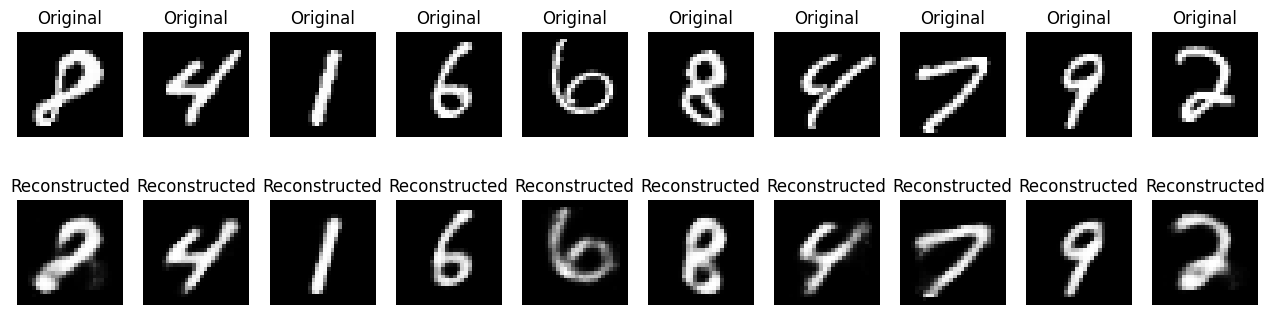

In [95]:
model.eval()

with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, 28 * 28).to(device)
    x_recons = model(x)
    x = x.cpu().numpy()

    n = 10
    plt.figure(figsize=(16, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x[i].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(x_recons[i].cpu().numpy().reshape(28, 28), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    plt.show()

In [96]:
model.eval()

latents = []
labels = []

with torch.no_grad():
    # Collect latent vectors for a quick look at the learned space.
    for batch in train_loader:
        x, y = batch
        x = x.view(-1, 28 * 28).to(device)
        z = model.encoder(x)
        latents.append(z.cpu().numpy())
        labels.append(y.numpy())

latents = np.concatenate(latents, axis=0)
labels = np.concatenate(labels, axis=0)

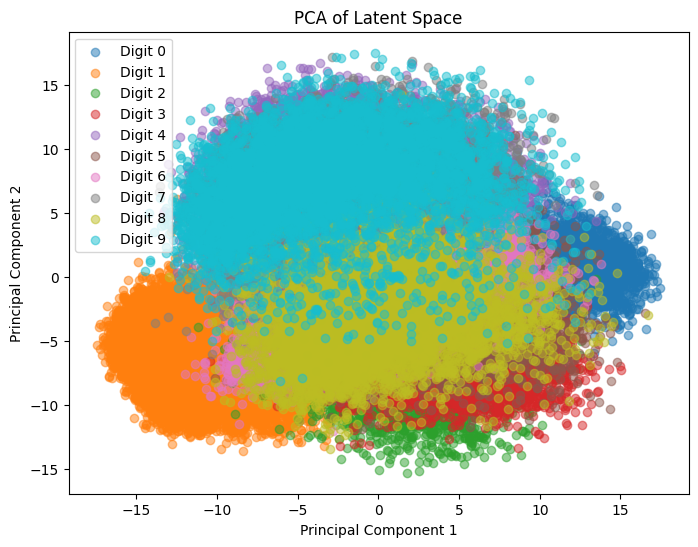

In [97]:
from sklearn.decomposition import PCA

latent_dim = latents.shape[1]

z = latents.detach().cpu().numpy() if torch.is_tensor(latents) else latents
y = labels.detach().cpu().numpy() if torch.is_tensor(labels) else labels


if latent_dim == 1 :
    plt.figure(figsize=(8, 6))
    for digit in range(10):
        plt.hist(
            z[y == digit],
            bins=30,
            alpha=0.5,
            label=f"Digit {digit}"
        )
    plt.title("Distribution of 1D Latent Space")
    plt.xlabel("Latent Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

elif latent_dim == 2:
    plt.figure(figsize=(8, 6))
    for digit in range(10):
        plt.scatter(
            z[y == digit, 0],
            z[y == digit, 1],
            alpha=0.5,
            label=f"Digit {digit}"
        )
    plt.title("2D Latent Space Visualization")
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.legend()
    plt.show()

elif latent_dim == 3:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    for digit in range(10):
        ax.scatter(
            z[y == digit, 0],
            z[y == digit, 1],
            z[y == digit, 2],
            cmap='tab10', s=5,
            alpha=0.7,
            label=f"Digit {digit}"
        )
    ax.set_title("3D Latent Space Visualization")
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.set_zlabel("z3")
    ax.legend()
    plt.show()

else:
    # Use PCA to project larger latent spaces into 2D for plotting.
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z)

    plt.figure(figsize=(8, 6))
    for digit in range(10):
        plt.scatter(
            z_2d[y == digit, 0],
            z_2d[y == digit, 1],
            alpha=0.5,
            label=f"Digit {digit}"
        )
    plt.title("PCA of Latent Space")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.show()

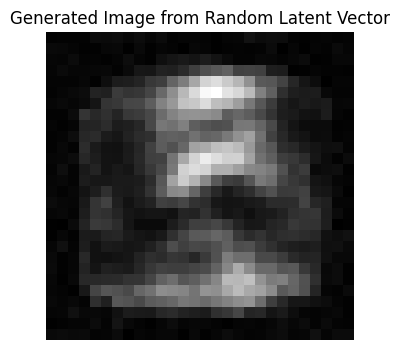

In [116]:
model.eval()
with torch.no_grad():
    # Sample a random latent vector and decode it back to image space.
    latent_dim = model.encoder[-1].out_features
    z_random = torch.randn(1, latent_dim).to(device)
    x_generated = model.decoder(z_random)
    x_generated = x_generated.cpu().view(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(x_generated, cmap='gray')    
plt.axis('off')
plt.title("Generated Image from Random Latent Vector")
plt.show()